In [137]:
import numpy as np
import pandas as pd
from matplotlib .pyplot import subplots
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF
from statsmodels.stats.anova import anova_lm
from ISLP import load_data
from ISLP.models import ( ModelSpec as MS ,summarize ,poly)

In [92]:
A = np.array ([3 ,5 ,11])
A.sum()

19

In [93]:
Boston = load_data("Boston")
Boston.columns

Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'lstat', 'medv'],
      dtype='object')

### SLR

In [94]:
X = pd. DataFrame ({'intercept ': np.ones(Boston.shape [0]) ,
'lstat ': Boston['lstat']})
X[:4]

,intercept,lstat
0,1.0,4.98
1,1.0,9.14
2,1.0,4.03
3,1.0,2.94


In [95]:
y = Boston['medv']
model = sm.OLS(y, X)
results = model.fit()
summarize (results)

,coef,std err,t,P>|t|
intercept,34.5538,0.563,61.415,0.0
lstat,-0.9500,0.039,-24.528,0.0


#### in the ISLP library. ModelSpec() creates a transform object, and then a pair of methods transform() and fit() are used to construct a corresponding model matrix. sklearn package 

In [96]:
design = MS(['lstat'])
design = design.fit(Boston)
X = design.transform(Boston)
X[:4]

,intercept,lstat
0,1.0,4.98
1,1.0,9.14
2,1.0,4.03
3,1.0,2.94


In [97]:
results.summary ()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   medv   R-squared:                       0.544
Model:                            OLS   Adj. R-squared:                  0.543
Method:                 Least Squares   F-statistic:                     601.6
Date:                Fri, 03 Jan 2025   Prob (F-statistic):           5.08e-88
Time:                        12:21:46   Log-Likelihood:                -1641.5
No. Observations:                 506   AIC:                             3287.
Df Residuals:                     504   BIC:                             3295.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     34.5538      0.563     61.415      0.000      33.448      35.659
lstat         -0.9500      0.039    -24.528      0.000      -1.026      -0.874
==============================================================================
Omnibus:                      137.043   Durbin-Watson:                   0.892
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              291.373
Skew:                           1.453   Prob(JB):                     5.36e-64
Kurtosis:                       5.319   Cond. No.                         29.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [98]:
results.params

intercept     34.553841
lstat         -0.950049
dtype: float64

In [99]:
new_df = pd.DataFrame ({'lstat':[5, 10, 15]})
newX = design.transform (new_df)
newX

,intercept,lstat
0,1.0,5
1,1.0,10
2,1.0,15


In [100]:
new_predictions = results. get_prediction (newX);
new_predictions . predicted_mean

array([29.80359411, 25.05334734, 20.30310057])

In [101]:
new_predictions . conf_int (alpha =0.05)

array([[29.00741194, 30.59977628],
       [24.47413202, 25.63256267],
       [19.73158815, 20.87461299]])

In [102]:
new_predictions . conf_int (obs=True , alpha =0.05)

array([[17.56567478, 42.04151344],
       [12.82762635, 37.27906833],
       [ 8.0777421 , 32.52845905]])

In [103]:
def abline(ax , b, m, *args , ** kwargs):
    "Add a line with slope m and intercept b to ax"
    xlim = ax. get_xlim ()
    ylim = [m * xlim [0] + b, m * xlim [1] + b]
    ax.plot(xlim , ylim , *args , ** kwargs)

#The addition of *args allows any number of non-named arguments to abline, while *kwargs allows any number of named arguments (such aslinewidth=3) to abline.

/var/folders/17/14yr79k910x66sv3lk_p0fjw0000gn/T/ipykernel_41571/1142215236.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  results.params [0],
/var/folders/17/14yr79k910x66sv3lk_p0fjw0000gn/T/ipykernel_41571/1142215236.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  results.params [1],


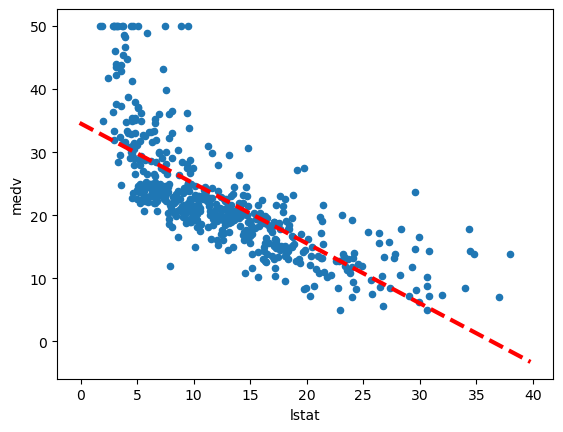

In [104]:
ax = Boston.plot.scatter('lstat', 'medv')
abline(ax ,
    results.params [0],
    results.params [1],
    'r--',
    linewidth =3)

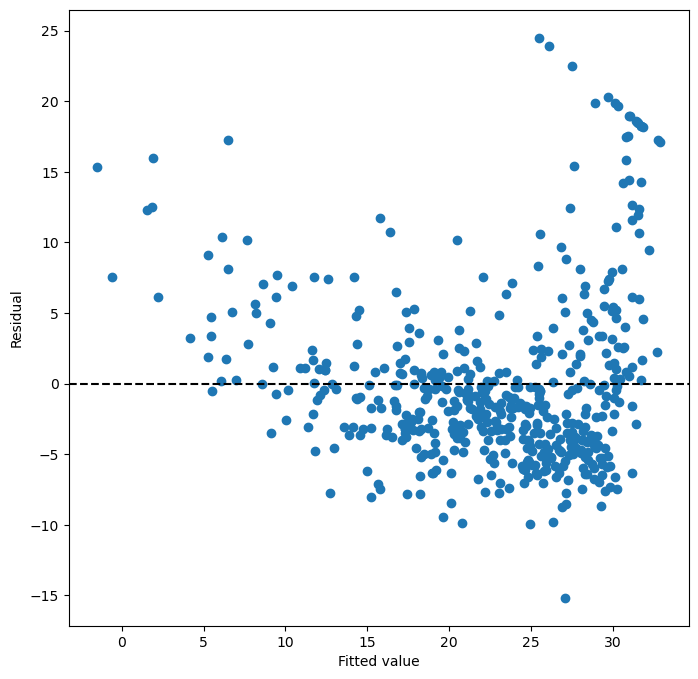

In [105]:
ax = subplots (figsize =(8 ,8))[1]
ax.scatter(results.fittedvalues , results.resid)
ax.set_xlabel ('Fitted value')
ax.set_ylabel ('Residual')
ax.axhline (0, c='k', ls='--');

374

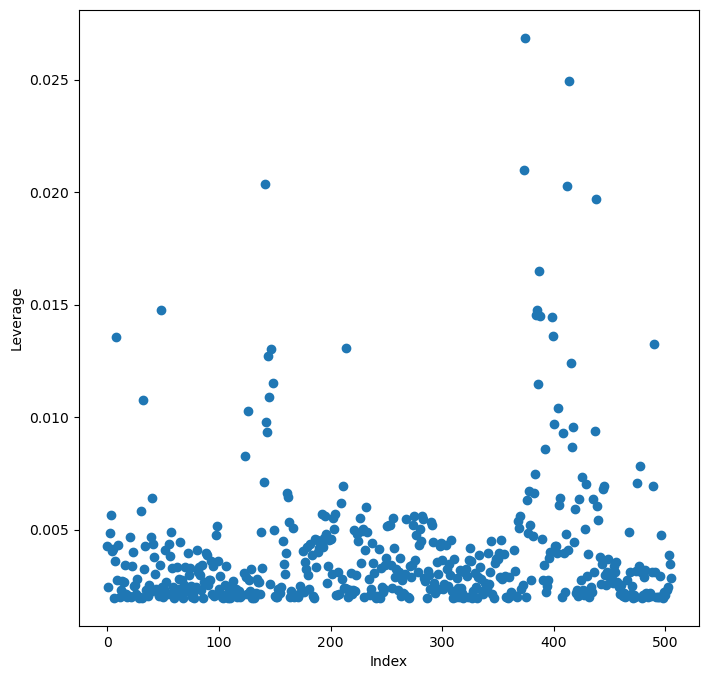

In [106]:
infl = results. get_influence ()
ax = subplots (figsize =(8 ,8))[1]
ax.scatter(np.arange(X.shape [0]) , infl.hat_matrix_diag )
ax. set_xlabel ('Index')
ax. set_ylabel ('Leverage')
np.argmax(infl.hat_matrix_diag )

### MLR

In [79]:
X = MS(['lstat', 'age']). fit_transform (Boston)
model1 = sm.OLS(y, X)
results1 = model1.fit ()
summarize ( results1 )

,coef,std err,t,P>|t|
intercept,33.2228,0.731,45.458,0.000
lstat,-1.0321,0.048,-21.416,0.000
age,0.0345,0.012,2.826,0.005


In [107]:
terms = Boston.columns.drop('medv')
terms

Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'lstat'],
      dtype='object')

In [110]:
X = MS(terms).fit_transform(Boston)
model = sm.OLS(y, X)
results = model.fit ()
summarize(results)

,coef,std err,t,P>|t|
intercept,41.6173,4.936,8.431,0.000
crim,-0.1214,0.033,-3.678,0.000
zn,0.0470,0.014,3.384,0.001
indus,0.0135,0.062,0.217,0.829
chas,2.8400,0.870,3.264,0.001
nox,-18.7580,3.851,-4.870,0.000
rm,3.6581,0.420,8.705,0.000
age,0.0036,0.013,0.271,0.787
dis,-1.4908,0.202,-7.394,0.000
rad,0.2894,0.067,4.325,0.000


In [111]:
minus_age = Boston.columns.drop (['medv', 'age'])
Xma = MS( minus_age ). fit_transform (Boston)
model1 = sm.OLS(y, Xma)
summarize (model1.fit())

,coef,std err,t,P>|t|
intercept,41.5251,4.920,8.441,0.000
crim,-0.1214,0.033,-3.683,0.000
zn,0.0465,0.014,3.379,0.001
indus,0.0135,0.062,0.217,0.829
chas,2.8528,0.868,3.287,0.001
nox,-18.4851,3.714,-4.978,0.000
rm,3.6811,0.411,8.951,0.000
dis,-1.5068,0.193,-7.825,0.000
rad,0.2879,0.067,4.322,0.000
tax,-0.0127,0.004,-3.333,0.001


In [112]:
vals = [VIF(X, i)
    for i in range (1, X.shape [1])]
vif = pd. DataFrame ({'vif ':vals},
    index=X.columns [1:])
vif

,vif
crim,1.767486
zn,2.298459
indus,3.987181
chas,1.071168
nox,4.369093
rm,1.912532
age,3.088232
dis,3.954037
rad,7.445301
tax,9.002158


In [113]:
vals = []
for i in range (1, X.values.shape [1]):
    vals.append(VIF(X.values , i))
vals

[1.767485915431012,
 2.298458907735808,
 3.9871806307570994,
 1.0711677737584047,
 4.369092622844795,
 1.912532437436886,
 3.0882320397311984,
 3.954036641628298,
 7.445300760069844,
 9.002157663471797,
 1.797059593129781,
 2.8707765008417505]

##### Interaction Terms

In [85]:
X = MS(['lstat',
    'age',
    ('lstat', 'age')]). fit_transform (Boston)
model2 = sm.OLS(y, X)
summarize (model2.fit ())

,coef,std err,t,P>|t|
intercept,36.0885,1.470,24.553,0.000
lstat,-1.3921,0.167,-8.313,0.000
age,-0.0007,0.020,-0.036,0.971
lstat:age,0.0042,0.002,2.244,0.025


In [86]:
X = MS([ poly('lstat', degree =2) , 'age']). fit_transform (Boston)
model3 = sm.OLS(y, X)
results3 = model3.fit ()
summarize ( results3 )

,coef,std err,t,P>|t|
intercept,17.7151,0.781,22.681,0.0
"poly(lstat, degree=2)[0]",-179.2279,6.733,-26.620,0.0
"poly(lstat, degree=2)[1]",72.9908,5.482,13.315,0.0
age,0.0703,0.011,6.471,0.0


In [87]:
anova_lm(results1 , results3 )

/Users/scarlettattensil/anaconda3/lib/python3.10/site-packages/statsmodels/stats/anova.py:374: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  table[pr_test][table['F'].isnull()] = np.nan


,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,503.0,19168.128609,0.0,NaN,NaN,NaN
1,502.0,14165.613251,1.0,5002.515357,177.278785,7.468491e-35


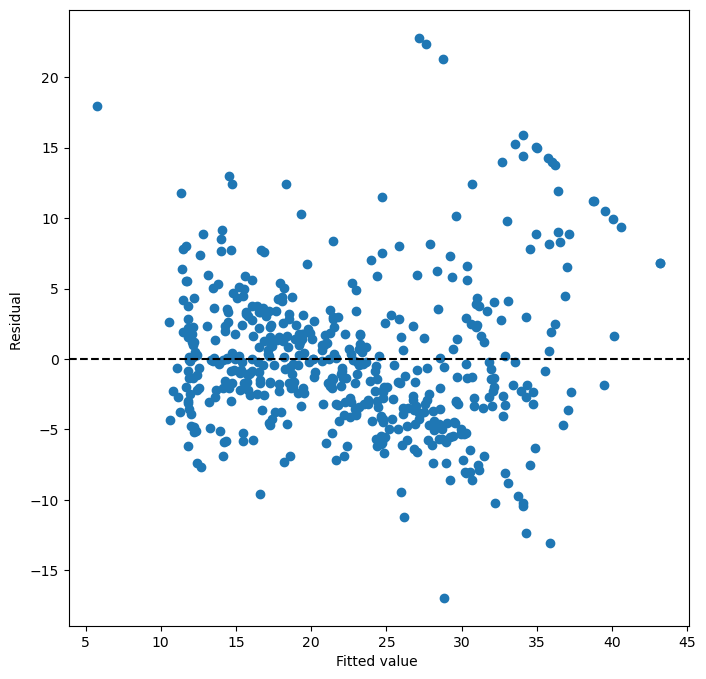

In [88]:
ax = subplots (figsize =(8 ,8))[1]
ax.scatter( results3 .fittedvalues , results3.resid)
ax. set_xlabel ('Fitted value ')
ax. set_ylabel ('Residual ')
ax.axhline (0, c='k', ls='--')

In [89]:
Carseats = load_data ('Carseats')
Carseats .columns

Index(['Sales', 'CompPrice', 'Income', 'Advertising', 'Population', 'Price',
       'ShelveLoc', 'Age', 'Education', 'Urban', 'US'],
      dtype='object')

In [90]:
allvars = list(Carseats .columns.drop('Sales'))
y = Carseats ['Sales']
final = allvars + [('Income', 'Advertising'),
    ('Price', 'Age')]
X = MS(final). fit_transform ( Carseats )
model = sm.OLS(y, X)
summarize (model.fit ())

,coef,std err,t,P>|t|
intercept,6.5756,1.009,6.519,0.000
CompPrice,0.0929,0.004,22.567,0.000
Income,0.0109,0.003,4.183,0.000
Advertising,0.0702,0.023,3.107,0.002
Population,0.0002,0.000,0.433,0.665
Price,-0.1008,0.007,-13.549,0.000
ShelveLoc[Good],4.8487,0.153,31.724,0.000
ShelveLoc[Medium],1.9533,0.126,15.531,0.000
Age,-0.0579,0.016,-3.633,0.000
Education,-0.0209,0.020,-1.063,0.288


##### Tensorflow

In [122]:
Boston[['lstat']].values

array([[ 4.98],
       [ 9.14],
       [ 4.03],
       [ 2.94],
       [ 5.33],
       [ 5.21],
       [12.43],
       [19.15],
       [29.93],
       [17.1 ],
       [20.45],
       [13.27],
       [15.71],
       [ 8.26],
       [10.26],
       [ 8.47],
       [ 6.58],
       [14.67],
       [11.69],
       [11.28],
       [21.02],
       [13.83],
       [18.72],
       [19.88],
       [16.3 ],
       [16.51],
       [14.81],
       [17.28],
       [12.8 ],
       [11.98],
       [22.6 ],
       [13.04],
       [27.71],
       [18.35],
       [20.34],
       [ 9.68],
       [11.41],
       [ 8.77],
       [10.13],
       [ 4.32],
       [ 1.98],
       [ 4.84],
       [ 5.81],
       [ 7.44],
       [ 9.55],
       [10.21],
       [14.15],
       [18.8 ],
       [30.81],
       [16.2 ],
       [13.45],
       [ 9.43],
       [ 5.28],
       [ 8.43],
       [14.8 ],
       [ 4.81],
       [ 5.77],
       [ 3.95],
       [ 6.86],
       [ 9.22],
       [13.15],
       [14.44],
       [

In [180]:
import numpy as np
import statsmodels.api as sm
import pandas as pd

# Assuming you have the Boston dataset loaded as 'Boston'
# Add intercept to the X values (sm.add_constant automatically adds a constant column of ones)
X = sm.add_constant(Boston['lstat'])  # Add constant column for the intercept

# Define the dependent variable
y = Boston['medv']

# Fit the OLS model
model = sm.OLS(y, X).fit()

# Now you can get the fitted values (predictions)
y_pred = model.fittedvalues  # This is the predicted values from the model

# Calculate SST (Total Sum of Squares), SSR (Regression Sum of Squares), and SSE (Error Sum of Squares)
y_mean = np.mean(y)  # Mean of y
SST = np.sum((y - y_mean) ** 2)  # Total Sum of Squares
SSR = np.sum((y_pred - y_mean) ** 2)  # Regression Sum of Squares
SSE = np.sum((y - y_pred) ** 2)  # Error Sum of Squares

# Degrees of freedom
n = len(y)  # Number of data points
p = X.shape[1] - 1  # Number of predictors (excluding intercept)

df_model = p  # Degrees of freedom for the model
df_residual = n - p - 1  # Degrees of freedom for the residuals

# Calculate the F-statistic
F_stat = (SSR / df_model) / (SSE / df_residual)

# Display Results
print(f"SST: {SST}")
print(f"SSR: {SSR}")
print(f"SSE: {SSE}")
print(f"F-statistic: {F_stat}")

SST: 42716.29541501977
SSR: 23243.913996693285
SSE: 19472.381418326437
F-statistic: 601.6178711098943


In [181]:
# Get the predicted values
y_pred = model.predict(X) 

# Calculate SST, SSR, SSE
y_mean = y.mean()
SST = ((y - y_mean) ** 2).sum()  # Total Sum of Squares
SSR = ((y_pred - y_mean) ** 2).sum()  # Regression Sum of Squares
SSE = ((y - y_pred) ** 2).sum()  # Error Sum of Squares

# Degrees of freedom
n = len(y)  # Number of data points
p = X.shape[1] - 1  # Number of predictors (excluding intercept)

df_model = p  # Degrees of freedom for the model
df_residual = n - p - 1  # Degrees of freedom for the residuals

# Calculate F-statistic
F_stat = (SSR / df_model) / (SSE / df_residual)

# Output the components
print(f"SST: {SST}")
print(f"SSR: {SSR}")
print(f"SSE: {SSE}")
print(f"F-statistic: {F_stat}")
print(model.summary())

SST: 42716.29541501977
SSR: 23243.913996693285
SSE: 19472.381418326437
F-statistic: 601.6178711098943
                            OLS Regression Results                            
Dep. Variable:                   medv   R-squared:                       0.544
Model:                            OLS   Adj. R-squared:                  0.543
Method:                 Least Squares   F-statistic:                     601.6
Date:                Fri, 03 Jan 2025   Prob (F-statistic):           5.08e-88
Time:                        16:03:13   Log-Likelihood:                -1641.5
No. Observations:                 506   AIC:                             3287.
Df Residuals:                     504   BIC:                             3295.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------

##### Tensorflow Manual

Epoch 50: cost = 160.70541381835938, W = 1.1056238412857056, b = 0.3137893080711365
Epoch 100: cost = 157.34552001953125, W = 1.0810693502426147, b = 0.7228477001190186
Epoch 150: cost = 154.0654296875, W = 1.0568040609359741, b = 1.127018928527832
Epoch 200: cost = 150.86326599121094, W = 1.032828688621521, b = 1.5263617038726807
Epoch 250: cost = 147.7371368408203, W = 1.0091395378112793, b = 1.920933723449707
Epoch 300: cost = 144.6852569580078, W = 0.9857337474822998, b = 2.3107917308807373
Epoch 350: cost = 141.7058563232422, W = 0.9626073241233826, b = 2.6959924697875977
Epoch 400: cost = 138.79722595214844, W = 0.939757227897644, b = 3.0765912532806396
Epoch 450: cost = 135.95765686035156, W = 0.9171801805496216, b = 3.4526429176330566
Epoch 500: cost = 133.1855926513672, W = 0.894872784614563, b = 3.824201822280884
Epoch 550: cost = 130.47930908203125, W = 0.8728319406509399, b = 4.191321849822998
Epoch 600: cost = 127.8373031616211, W = 0.851054310798645, b = 4.554057121276855

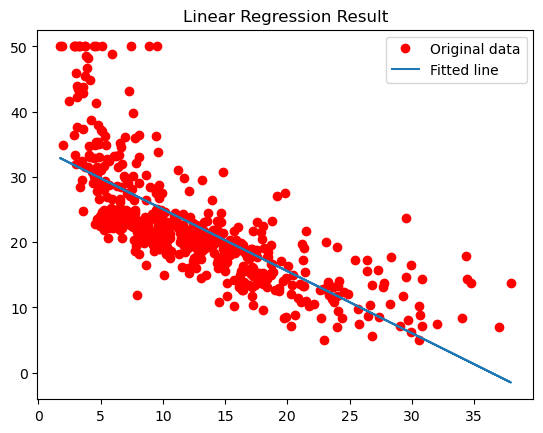

In [156]:
import tensorflow as tf
import random
import matplotlib.pyplot as plt


# Set seeds for reproducibility
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

X = pd.DataFrame({
    'intercept': np.ones(Boston.shape[0]),
    'lstat': Boston['lstat']
}).values 
y = Boston['medv'].values

# Convert data to tensors
X_tensor = tf.constant(X, dtype=tf.float32)
y_tensor = tf.constant(y, dtype=tf.float32)

learning_rate = 0.001
training_epochs = 100000
n = X_tensor.shape[0]  # Number of data points

W = tf.Variable(np.random.randn(), name="W")
b = tf.Variable(np.random.randn(), name="b")

# Hypothesis
y_pred = tf.add(tf.multiply(X_tensor[:, 1], W), b)  # Take only the 'lstat' column for prediction

# Mean Squared Error Cost Function
epsilon = 1e-8
cost = tf.reduce_sum(tf.pow(y_pred - y_tensor, 2)) / (2 * n + epsilon)

# Gradient Descent Optimizer
optimizer = tf.optimizers.SGD(learning_rate)

# Training Loop
for epoch in range(training_epochs):
    with tf.GradientTape() as tape:
        y_pred = tf.add(tf.multiply(X_tensor[:, 1], W), b)  # Predict using 'lstat' column
        cost = tf.reduce_sum(tf.pow(y_pred - y_tensor, 2)) / (2 * n)
    
    # Compute gradients and apply updates
    gradients = tape.gradient(cost, [W, b])
    optimizer.apply_gradients(zip(gradients, [W, b]))

    # Displaying the result after every 50 epochs
    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch + 1}: cost = {cost.numpy()}, W = {W.numpy()}, b = {b.numpy()}")

# Final output after training
weight = W.numpy()
bias = b.numpy()

# Calculating the predictions
predictions = weight * X_tensor[:, 1] + bias
print(f"Training cost = {cost.numpy()}, Weight = {weight}, Bias = {bias}\n")

# Plotting the Results
plt.plot(X_tensor[:, 1], y, 'ro', label='Original data')
plt.plot(X_tensor[:, 1], predictions, label='Fitted line')
plt.title('Linear Regression Result')
plt.legend()
plt.show()

##### Tensorflow Keras

16/16 [==============================] - 0s 6ms/step
Intercept (bias): [34.54594]
Slope (for LSTAT): [[-0.9466208]]
SST: 42716.293
SSR: 23077.088
SSE: 19473.322
R2: 0.5441242456436157
F-statistic: 597.2710839077621


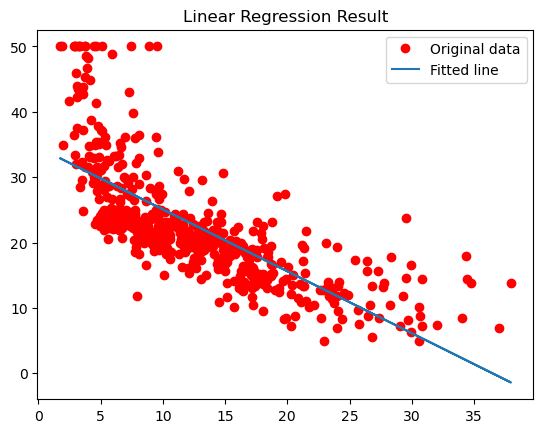

In [190]:
import numpy as np
import pandas as pd
import tensorflow as tf
import random
import matplotlib.pyplot as plt

# Set seeds for reproducibility
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

X = pd.DataFrame({
    #'intercept': np.ones(Boston.shape[0]),
    'lstat': Boston['lstat']
}).values 
y = Boston['medv'].values

# Convert data to tensors
X_tensor = tf.constant(X, dtype=tf.float32)
y_tensor = tf.constant(y, dtype=tf.float32)

# Define a simple linear regression model using Keras
model = tf.keras.Sequential([
    tf.keras.layers.Dense(units=1, input_dim=1) 
])

# Compile the model with SGD optimizer and MSE loss
model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.001), loss='mean_squared_error')

# Train the model
model.fit(X_tensor, y_tensor, epochs=10000, verbose=0)

# Predictions
y_pred = model.predict(X_tensor).flatten()

# Output the coefficients
weights = model.get_weights()  # This returns a list of arrays: [weights, bias]
slope = weights[0]  # The first element is the weights (slope for each feature)
intercept = weights[1]  # The second element is the bias (intercept)

# Display the output
print("Intercept (bias):", intercept)
print("Slope (for LSTAT):", slope)

# Calculate R2 and F-statistic
y_mean = tf.reduce_mean(y_tensor)
SST = tf.reduce_sum((y_tensor - y_mean) ** 2).numpy()  # Total sum of squares
SSR = tf.reduce_sum((y_pred - y_mean) ** 2).numpy()  # Regression sum of squares
SSE = tf.reduce_sum((y_tensor - tf.constant(y_pred, dtype=tf.float32)) ** 2).numpy()  # Error sum of squares

# Degrees of freedom
n = len(X)
p = 1
df_model = p  
df_residual = n - p -1

# F-statistic
F_stat = (SSR / df_model) / (SSE / df_residual)

# Print metrics
print("SST:", SST)
print("SSR:", SSR)
print("SSE:", SSE)
print("R2:", 1 - (SSE / SST))
print("F-statistic:", F_stat)

# Plot the Results
plt.plot(X_tensor, y, 'ro', label='Original data')  # Only using the 'lstat' feature for plotting
plt.plot(X_tensor, y_pred, label='Fitted line')
plt.title('Linear Regression Result')
plt.legend()
plt.show()


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

# Define and train a linear model
model = nn.Linear(1, 1)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.1)

for epoch in range(100):
    optimizer.zero_grad()
    predictions = model(X)
    loss = criterion(predictions, y)
    loss.backward()
    optimizer.step()

# Predictions
y_pred = model(X)

# Compute ANOVA metrics
y_mean = torch.mean(y)
SST = torch.sum((y - y_mean) ** 2)
SSR = torch.sum((y_pred - y_mean) ** 2)
SSE = torch.sum((y - y_pred) ** 2)

# Calculate degrees of freedom
n = X.shape[0]
p = X.shape[1]
df_model = p
df_residual = n - p - 1

# Calculate F-statistic
F_stat = (SSR / df_model) / (SSE / df_residual)

print("SST:", SST.item())
print("SSR:", SSR.item())
print("SSE:", SSE.item())
print("F-statistic:", F_stat.item())
